<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Real_World_AI_Driven_Analytics_Project_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import Libraries**
This section imports the Python libraries required for data manipulation, visualization, preprocessing, model development, and evaluation. Pandas and NumPy are used for data processing, Matplotlib and Seaborn for visualization, and scikit-learn for preprocessing, Random Forest classification, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# File handling
import os
import zipfile

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab
from google.colab import files

# Preprocessing and model development
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Initial model
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### **Dataset Exploration and Preprocessing**
This section loads and examines the Diabetes 130-US Hospitals dataset to understand its structure, feature types, and data quality. Missing-value indicators are standardized, duplicate records and missing data are assessed, and selected high-missing features are removed.

A binary target variable is then created to represent 30-day readmission, where 1 indicates readmission within 30 days and 0 indicates no readmission within 30 days. Readable feature labels are also created for use in tables and visualizations.

**Upload, Extract, and Load Dataset**

In [2]:
from google.colab import files
import zipfile
import os

# Upload the UCI dataset ZIP file
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

print(f"Extracting {zip_name}...")

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("/content")

# Locate diabetic_data.csv
csv_path = None

for root, dirs, files_in_dir in os.walk("/content"):
    if "diabetic_data.csv" in files_in_dir:
        csv_path = os.path.join(root, "diabetic_data.csv")
        break

if csv_path is None:
    raise FileNotFoundError("diabetic_data.csv was not found.")

# Load dataset
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.sample(5, random_state=42))

Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip
Extracting diabetes+130-us+hospitals+for+years+1999-2008.zip...
Dataset loaded successfully.
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


**Initial Dataset Inspection**

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Sample:")
display(df.sample(5, random_state=42))

Dataset Shape:
(101766, 53)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_label', 'discharge_disposition_label', 'admission_source_label']

Data Types:


,Data Type
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



Dataset Sample:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_label,discharge_disposition_label,admission_source_label
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Transfer from another health care facility
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Physician Referral
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Elective,Discharged/transferred to home with home healt...,Physician Referral
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30,Urgent,Discharged to home,Physician Referral
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30,Emergency,Discharged/transferred to another short term h...,Emergency Room


**Data Quality Assessment**

In [6]:
# Convert UCI missing-value marker to NaN
df = df.replace("?", np.nan)

# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().mean() * 100).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
    .sort_values("Missing Percent", ascending=False)
)

display(missing_summary)

Duplicate Rows: 0


,Missing Count,Missing Percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


**Remove High-Missing and Non-Useful Features**

In [7]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Dataset shape after removing selected columns:", df.shape)

Dataset shape after removing selected columns: (101766, 50)


**Load UCI ID Mappings**

In [3]:
# ============================================================
# Load UCI Administrative ID Mappings
# ============================================================

# Locate IDS_mapping.csv in the extracted UCI dataset
mapping_path = None

for root, dirs, files_in_dir in os.walk("/content"):
    if "IDS_mapping.csv" in files_in_dir:
        mapping_path = os.path.join(root, "IDS_mapping.csv")
        break

if mapping_path is None:
    raise FileNotFoundError(
        "IDS_mapping.csv was not found in the extracted dataset."
    )

print("Mapping file found:", mapping_path)


# ------------------------------------------------------------
# Read raw mapping file
# ------------------------------------------------------------
mapping_raw = pd.read_csv(
    mapping_path,
    header=None,
    dtype=str
)

# Keep first two columns
mapping_raw = mapping_raw.iloc[:, :2].copy()
mapping_raw.columns = ["id", "description"]

# Clean whitespace
mapping_raw["id"] = mapping_raw["id"].str.strip()
mapping_raw["description"] = (
    mapping_raw["description"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Function to extract an individual mapping section
# ------------------------------------------------------------
mapping_sections = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]


def extract_id_mapping(section_name):

    # Find start of requested section
    section_rows = mapping_raw.index[
        mapping_raw["id"].eq(section_name)
    ]

    if len(section_rows) == 0:
        raise ValueError(
            f"{section_name} was not found in IDS_mapping.csv."
        )

    start = section_rows[0] + 1

    # Find start of next section
    next_sections = mapping_raw.index[
        (mapping_raw.index >= start) &
        (mapping_raw["id"].isin(mapping_sections))
    ]

    end = (
        next_sections[0]
        if len(next_sections) > 0
        else len(mapping_raw)
    )

    section = (
        mapping_raw.loc[
            start:end - 1,
            ["id", "description"]
        ]
        .copy()
    )

    # Convert ID values to numeric
    section["id"] = pd.to_numeric(
        section["id"],
        errors="coerce"
    )

    # Remove headings, blank rows, and non-ID values
    section = (
        section
        .dropna(subset=["id"])
        .assign(
            id=lambda x: x["id"].astype(int)
        )
    )

    # Return reusable dictionary
    return dict(
        zip(
            section["id"],
            section["description"]
        )
    )


# ------------------------------------------------------------
# Create mappings directly from IDS_mapping.csv
# ------------------------------------------------------------
admission_type_mapping = extract_id_mapping(
    "admission_type_id"
)

discharge_disposition_mapping = extract_id_mapping(
    "discharge_disposition_id"
)

admission_source_mapping = extract_id_mapping(
    "admission_source_id"
)


# ------------------------------------------------------------
# Validate mappings
# ------------------------------------------------------------
print(
    "Admission Type mappings:",
    len(admission_type_mapping)
)

print(
    "Discharge Disposition mappings:",
    len(discharge_disposition_mapping)
)

print(
    "Admission Source mappings:",
    len(admission_source_mapping)
)

print("\nUCI ID mappings loaded successfully.")

Mapping file found: /content/IDS_mapping.csv
Admission Type mappings: 8
Discharge Disposition mappings: 30
Admission Source mappings: 25

UCI ID mappings loaded successfully.


**Create Readable Administrative Category Labels**

In [4]:
df["admission_type_label"] = (
    df["admission_type_id"]
    .map(admission_type_mapping)
    .fillna("Unknown / Unmapped")
)

df["discharge_disposition_label"] = (
    df["discharge_disposition_id"]
    .map(discharge_disposition_mapping)
    .fillna("Unknown / Unmapped")
)

df["admission_source_label"] = (
    df["admission_source_id"]
    .map(admission_source_mapping)
    .fillna("Unknown / Unmapped")
)

print("Readable administrative labels created successfully.")

Readable administrative labels created successfully.


**Create Target Variable**


In [8]:
# Create binary target:
# 1 = Readmitted within 30 days
# 0 = Not readmitted within 30 days

df["readmitted_30"] = (
    df["readmitted"] == "<30"
).astype(int)

target_summary = pd.DataFrame({
    "Count": df["readmitted_30"].value_counts().sort_index(),
    "Percent": (
        df["readmitted_30"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "No 30-Day Readmission",
    "30-Day Readmission"
]

display(target_summary)

,Count,Percent
No 30-Day Readmission,90409,88.84
30-Day Readmission,11357,11.16


**Feature Labels Mapping**

In [33]:
""" Custom labels only for feature names that benefit
from clearer wording in plots and model interpretation.
Administrative category descriptions are handled separately
using the mappings parsed from IDS_mapping.csv."""

feature_labels = {
    "age": "Age Group",
    "time_in_hospital": "Time in Hospital",
    "num_lab_procedures": "Number of Lab Procedures",
    "num_procedures": "Number of Procedures",
    "num_medications": "Number of Medications",
    "number_outpatient": "Prior Outpatient Visits",
    "number_emergency": "Prior Emergency Visits",
    "number_inpatient": "Prior Inpatient Visits",
    "number_diagnoses": "Number of Diagnoses",
    "max_glu_serum": "Maximum Glucose Serum Result",
    "A1Cresult": "A1C Test Result",
    "change": "Medication Change",
    "diabetesMed": "Diabetes Medication Prescribed",
    "readmitted_30": "30-Day Readmission"
}

print("Readable feature labels created successfully.")

Readable feature labels created successfully.


### **Exploratory Data Analysis**
This section explores patterns associated with 30-day hospital readmission before model development. The analysis examines the target distribution, numerical feature associations, demographic patterns, prior healthcare utilization, selected clinical-care characteristics, and correlations among numerical variables.

The analysis also compares total encounters with unique patients to identify repeat encounters in the dataset. Exploratory associations are used to understand patterns in the data and should not be interpreted as evidence of causation or as model-derived feature importance.

**Target Distribution and Numerical Feature Relevance**

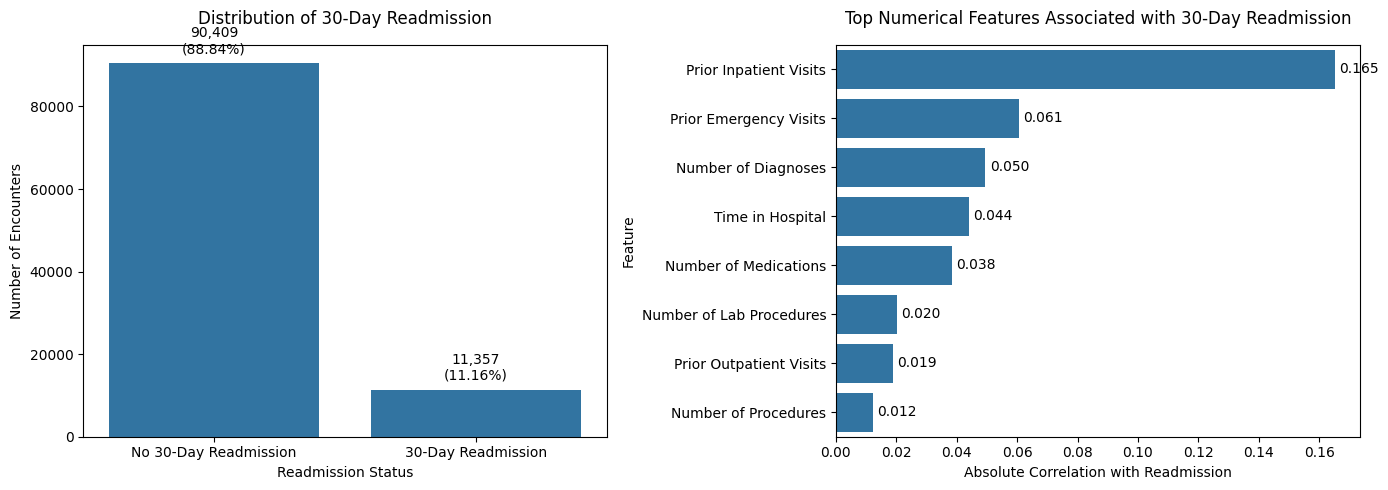

30-Day Readmission Summary by Race


,Race,Number of Encounters,Readmission Rate (%)
0,Caucasian,76099,11.29
1,AfricanAmerican,19210,11.22
2,Hispanic,2037,10.41
3,Asian,641,10.14
4,Other,1506,9.63


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# 1. Overall 30-Day Readmission Distribution
# ------------------------------------------------------------

ax1 = sns.countplot(
    data=df,
    x="readmitted_30",
    ax=axes[0]
)

axes[0].set_title(
    "Distribution of 30-Day Readmission",
    pad=15
)

axes[0].set_xlabel("Readmission Status")
axes[0].set_ylabel("Number of Encounters")

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(
    [
        "No 30-Day Readmission",
        "30-Day Readmission"
    ]
)

counts = (
    df["readmitted_30"]
    .value_counts()
    .sort_index()
)

percentages = (
    df["readmitted_30"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

for i, bar in enumerate(ax1.patches):
    count = counts.iloc[i]
    percent = percentages.iloc[i]

    ax1.annotate(
        f"{count:,}\n({percent:.2f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )


# ------------------------------------------------------------
# 2. Numerical Feature Relevance
# ------------------------------------------------------------

numeric_cols = (
    df.select_dtypes(include=np.number)
    .columns
    .difference([
        "encounter_id",
        "patient_nbr",
        "readmitted_30",
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ])
)

feature_relevance = (
    df[list(numeric_cols) + ["readmitted_30"]]
    .corr()["readmitted_30"]
    .drop("readmitted_30")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

feature_relevance.columns = [
    "Feature",
    "Absolute Correlation"
]

feature_relevance["Feature Label"] = (
    feature_relevance["Feature"]
    .map(feature_labels)
    .fillna(feature_relevance["Feature"])
)

ax2 = sns.barplot(
    data=feature_relevance,
    x="Absolute Correlation",
    y="Feature Label",
    ax=axes[1]
)

axes[1].set_title(
    "Top Numerical Features Associated with 30-Day Readmission",
    pad=15
)

axes[1].set_xlabel(
    "Absolute Correlation with Readmission"
)
axes[1].set_ylabel("Feature")

for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Race-Level Readmission Summary
# ------------------------------------------------------------

race_readmission = (
    df.dropna(subset=["race"])
    .groupby("race", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Convert readmission rate to percentage
race_readmission["Readmission Rate (%)"] = (
    race_readmission["mean"] * 100
)

# Create readable race summary table
race_summary = (
    race_readmission[
        ["race", "count", "Readmission Rate (%)"]
    ]
    .rename(
        columns={
            "race": "Race",
            "count": "Number of Encounters"
        }
    )
    .sort_values(
        "Readmission Rate (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

print("30-Day Readmission Summary by Race")

display(
    race_summary.round({
        "Readmission Rate (%)": 2
    })
)

**Demographic Patterns in 30-Day Readmission**

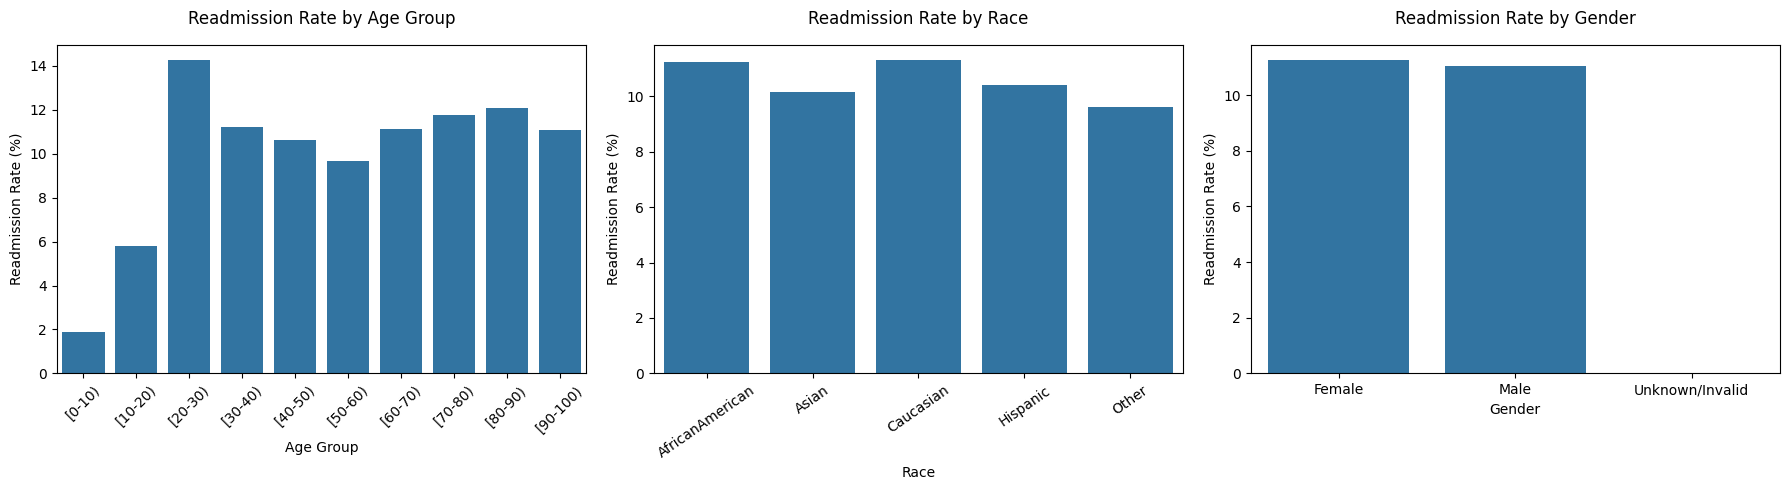

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------
# Age Group
# ------------------------------------------------------------

age_readmission = (
    df.groupby("age", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=age_readmission,
    x="age",
    y="Readmission Rate (%)",
    ax=axes[0]
)

axes[0].set_title(
    "Readmission Rate by Age Group",
    pad=15
)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].tick_params(axis="x", rotation=45)


# ------------------------------------------------------------
# Race
# ------------------------------------------------------------

race_readmission = (
    df.dropna(subset=["race"])
    .groupby("race", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=race_readmission,
    x="race",
    y="Readmission Rate (%)",
    ax=axes[1]
)

axes[1].set_title(
    "Readmission Rate by Race",
    pad=15
)
axes[1].set_xlabel("Race")
axes[1].set_ylabel("Readmission Rate (%)")
axes[1].tick_params(axis="x", rotation=35)


# ------------------------------------------------------------
# Gender
# ------------------------------------------------------------

gender_readmission = (
    df.groupby("gender", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=gender_readmission,
    x="gender",
    y="Readmission Rate (%)",
    ax=axes[2]
)

axes[2].set_title(
    "Readmission Rate by Gender",
    pad=15
)
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Prior Healthcare Utilization and Readmission**

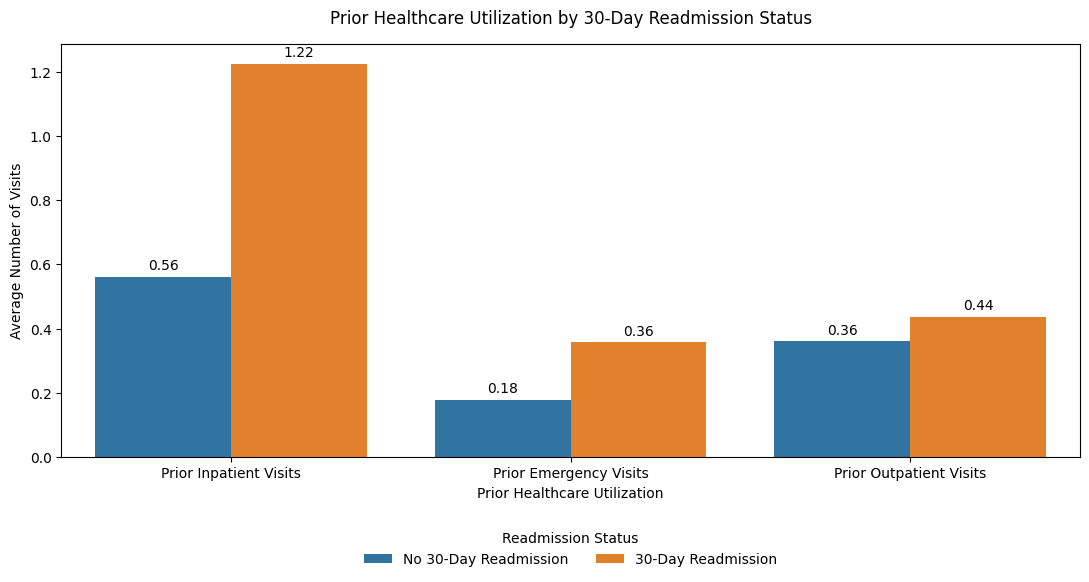

In [12]:
# ============================================================
# Prior Healthcare Utilization and 30-Day Readmission
# ============================================================

# Features representing healthcare utilization in the prior year
utilization_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

# Calculate average prior visits for each readmission group
utilization_summary = []

for feature in utilization_features:

    no_readmission_mean = df.loc[
        df["readmitted_30"] == 0,
        feature
    ].mean()

    readmission_mean = df.loc[
        df["readmitted_30"] == 1,
        feature
    ].mean()

    utilization_summary.append({
        "Feature": feature_labels.get(feature, feature),
        "No 30-Day Readmission": no_readmission_mean,
        "30-Day Readmission": readmission_mean
    })

# Convert results to DataFrame
utilization_df = pd.DataFrame(utilization_summary)

# Reshape for grouped bar chart
utilization_long = utilization_df.melt(
    id_vars="Feature",
    var_name="Readmission Status",
    value_name="Average Prior Visits"
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=utilization_long,
    x="Feature",
    y="Average Prior Visits",
    hue="Readmission Status"
)

plt.title(
    "Prior Healthcare Utilization by 30-Day Readmission Status",
    pad=15
)

plt.xlabel("Prior Healthcare Utilization")
plt.ylabel("Average Number of Visits")

# Add values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

# Place legend below the plot
plt.legend(
    title="Readmission Status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

**Discharge Disposition and 30-Day Readmission**

In [ ]:
discharge_summary = (
    df.groupby(
        "discharge_disposition_label",
        observed=False
    )["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

discharge_summary[
    "Readmission Rate (%)"
] = (
    discharge_summary["mean"]
    * 100
)

discharge_summary = (
    discharge_summary
    .rename(
        columns={
            "discharge_disposition_label":
                "Discharge Disposition",

            "count":
                "Number of Encounters"
        }
    )
)

# Select the 10 most common discharge destinations
top_dispositions = (
    discharge_summary
    .nlargest(
        10,
        "Number of Encounters"
    )
    .sort_values(
        "Readmission Rate (%)",
        ascending=False
    )
)

plt.figure(
    figsize=(11, 6)
)

ax = sns.barplot(
    data=top_dispositions,
    x="Readmission Rate (%)",
    y="Discharge Disposition"
)

plt.title(
    "30-Day Readmission Rate by Discharge Disposition",
    pad=15
)

plt.xlabel(
    "30-Day Readmission Rate (%)"
)

plt.ylabel(
    "Discharge Disposition"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

**Clinical Care and Testing Patterns**

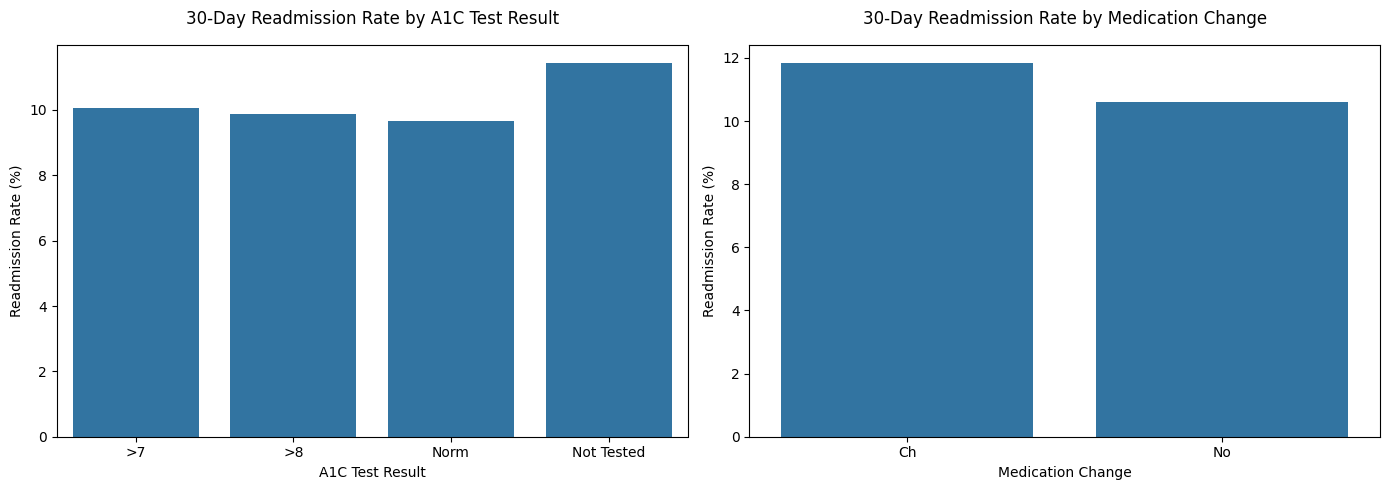

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# A1C Test Result
# ------------------------------------------------------------

a1c_readmission = (
    df.assign(
        A1C_Display=df["A1Cresult"].fillna("Not Tested")
    )
    .groupby("A1C_Display", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=a1c_readmission,
    x="A1C_Display",
    y="Readmission Rate (%)",
    ax=axes[0]
)

axes[0].set_title(
    "30-Day Readmission Rate by A1C Test Result",
    pad=15
)
axes[0].set_xlabel("A1C Test Result")
axes[0].set_ylabel("Readmission Rate (%)")


# ------------------------------------------------------------
# Medication Change
# ------------------------------------------------------------

change_readmission = (
    df.groupby("change", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=change_readmission,
    x="change",
    y="Readmission Rate (%)",
    ax=axes[1]
)

axes[1].set_title(
    "30-Day Readmission Rate by Medication Change",
    pad=15
)
axes[1].set_xlabel("Medication Change")
axes[1].set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Selected Numerical Feature Correlations**

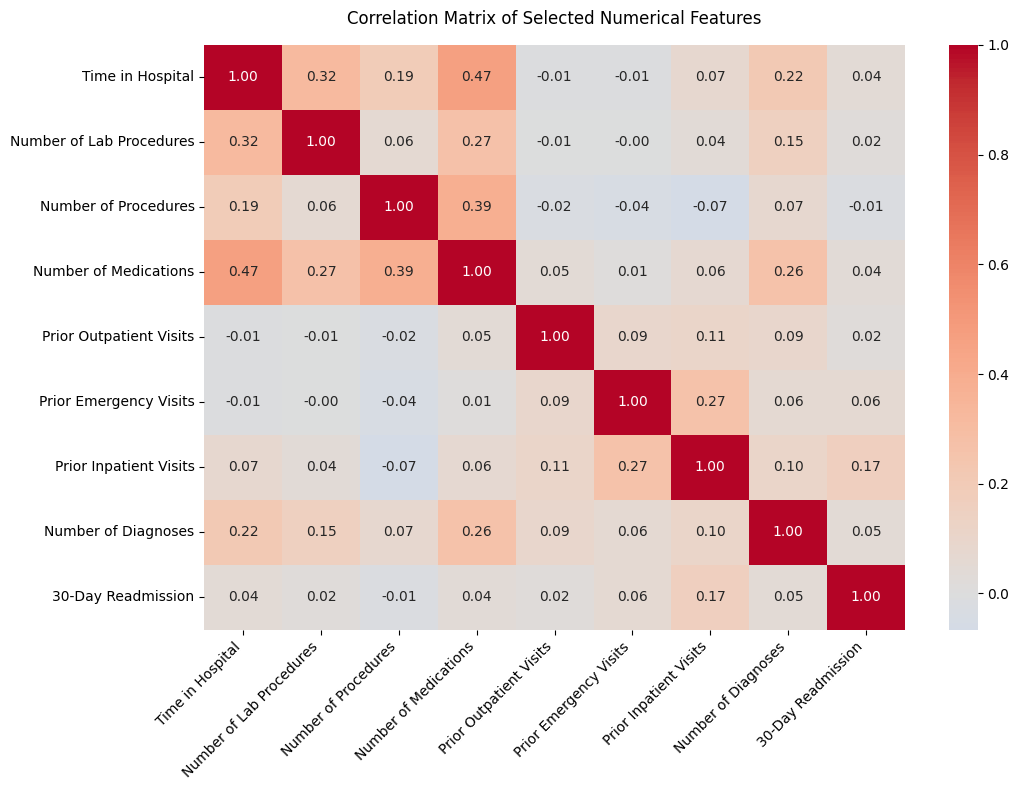

In [19]:
numeric_eda_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_30"
]

correlation_matrix = (
    df[numeric_eda_features]
    .corr()
)

readable_corr_labels = [
    feature_labels.get(feature, feature)
    for feature in correlation_matrix.columns
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=readable_corr_labels,
    yticklabels=readable_corr_labels
)

plt.title(
    "Correlation Matrix of Selected Numerical Features",
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Patient Encounter Assessment**

In [20]:
total_encounters = len(df)
unique_patients = df["patient_nbr"].nunique()
repeat_encounters = total_encounters - unique_patients

print(f"Total Encounters:  {total_encounters:,}")
print(f"Unique Patients:   {unique_patients:,}")
print(f"Repeat Encounters: {repeat_encounters:,}")

Total Encounters:  101,766
Unique Patients:   71,518
Repeat Encounters: 30,248


### **Feature Preparation**
This section prepares the dataset for machine learning by separating the predictor variables from the 30-day readmission target. Encounter ID and patient ID are excluded because they are identifiers, while the original readmission variable is excluded because the binary target was derived from it and retaining it would introduce target leakage.

The data is divided into training and testing sets using stratification to preserve the imbalanced target distribution. Numerical and categorical features are then identified so that appropriate preprocessing can be applied. Missing numerical values are imputed using the median, missing categorical values using the most frequent category, and categorical variables are transformed using one-hot encoding.

**Define Features and Target**

In [21]:
X = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted",
        "readmitted_30"
    ]
)

y = df["readmitted_30"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (101766, 47)
Target Shape: (101766,)


**Train-Test Split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Set: {X_train.shape}")
print(f"Testing Set:  {X_test.shape}")

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training Set: (81412, 47)
Testing Set:  (20354, 47)

Training Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64

Testing Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64


**Identify Numerical and Categorical Features**

In [23]:
categorical_id_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .difference(categorical_id_features)
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

categorical_features += categorical_id_features

print(f"Numerical Features:   {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features:   8
Categorical Features: 39


**Create Preprocessing Pipeline**

In [24]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### **Initial Model Development**
A Random Forest classifier is developed as the initial classification model for predicting 30-day hospital readmission. Random Forest is suitable for capturing complex and potentially nonlinear relationships across the numerical and categorical predictors produced by the preprocessing pipeline.

The classifier uses 100 decision trees and a fixed random state for reproducibility. Preprocessing and classification are combined within a single scikit-learn pipeline to provide a consistent workflow from raw features through prediction.

**Build and Train Initial Random Forest Model**

In [25]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Initial Random Forest model trained successfully.")

Initial Random Forest model trained successfully.


### **Model Evaluation**
This section evaluates the initial Random Forest on both the training and testing data. Training and testing accuracy are compared to assess generalization and identify potential overfitting.

Because the 30-day readmission target is imbalanced, model performance is evaluated using accuracy, precision, recall, F1 score, and ROC-AUC rather than accuracy alone. The classification report, confusion matrix, and ROC curve provide additional detail about the model's ability to distinguish between encounters with and without 30-day readmission.

The evaluation is particularly focused on performance for the minority 30-day readmission class because high overall accuracy can occur even when relatively few actual readmissions are correctly identified.

**Compare Training and Testing Accuracy**

In [26]:
train_accuracy = random_forest_model.score(
    X_train,
    y_train
)

test_accuracy = random_forest_model.score(
    X_test,
    y_test
)

accuracy_gap = (
    train_accuracy - test_accuracy
)

print("Training vs. Testing Accuracy")
print("-" * 35)

print(
    f"Training Accuracy: {train_accuracy:.4f}"
)

print(
    f"Testing Accuracy:  {test_accuracy:.4f}"
)

print(
    f"Accuracy Gap:      {accuracy_gap:.4f}"
)

Training vs. Testing Accuracy
-----------------------------------
Training Accuracy: 1.0000
Testing Accuracy:  0.8888
Accuracy Gap:      0.1111


**Evaluate Initial Model Performance**

In [27]:
# Generate predictions
y_pred = random_forest_model.predict(
    X_test
)

y_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# Performance table
model_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(
    model_performance.round(4)
)

,Metric,Score
0,Accuracy,0.8888
1,Precision,0.6667
2,Recall,0.0070
3,F1 Score,0.0139
4,ROC-AUC,0.6606


**Classification Report**

In [28]:
print("Classification Report")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No 30-Day Readmission",
            "30-Day Readmission"
        ],
        zero_division=0
    )
)

Classification Report
-------------------------------------------------------
                       precision    recall  f1-score   support

No 30-Day Readmission       0.89      1.00      0.94     18083
   30-Day Readmission       0.67      0.01      0.01      2271

             accuracy                           0.89     20354
            macro avg       0.78      0.50      0.48     20354
         weighted avg       0.86      0.89      0.84     20354



**Confusion Matrix and ROC Curve**

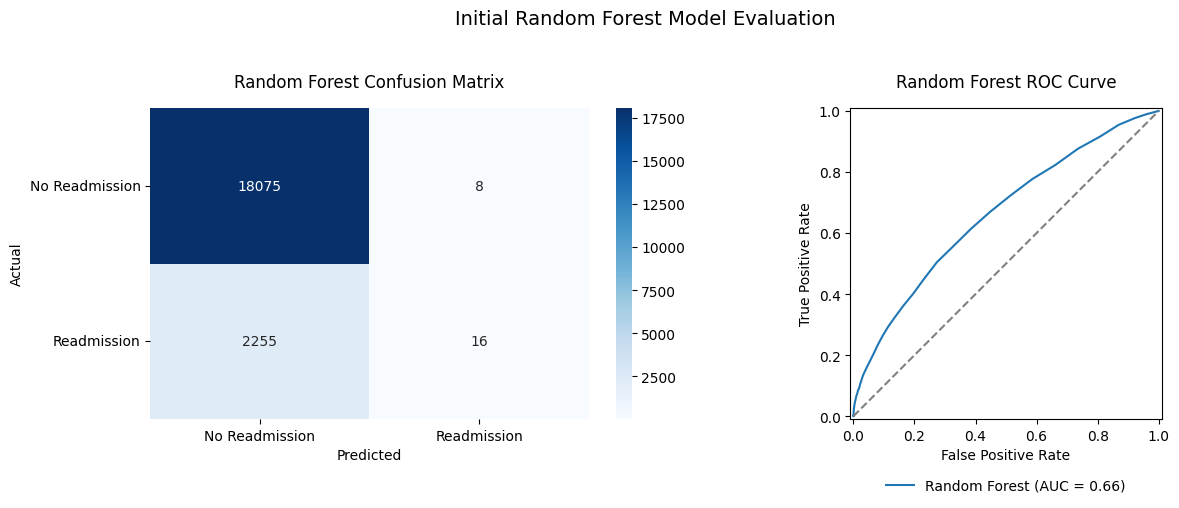

In [29]:
# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

# Create side-by-side figure
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest Confusion Matrix",
    pad=15
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticklabels(
    ["No Readmission", "Readmission"]
)

axes[0].set_yticklabels(
    ["No Readmission", "Readmission"],
    rotation=0
)

# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Random Forest",
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[1].set_title(
    "Random Forest ROC Curve",
    pad=15
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

fig.suptitle(
    "Initial Random Forest Model Evaluation",
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()

### **Feature Importance and Initial Model Summary**
I would combine these into the final main Colab section instead of creating separate Markdown cells.

Your notebook extracts Random Forest feature importance, converts transformed feature names into readable labels, visualizes the top 15 features, and concludes with the model performance summary.

**Feature Importance**

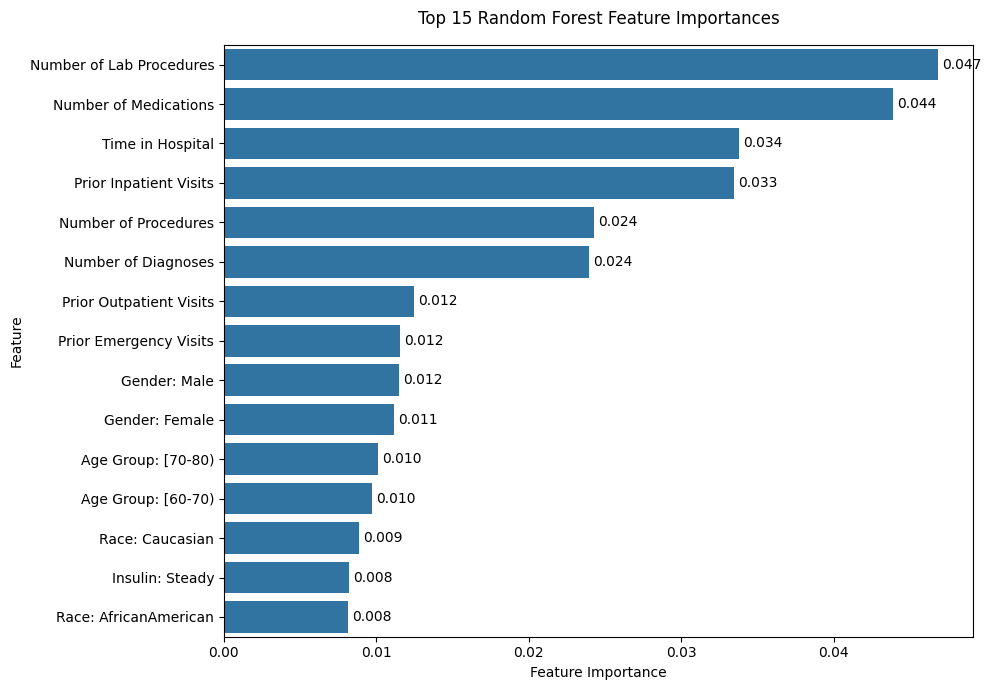

In [30]:
# Extract transformed feature names
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract fitted classifier
rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

# Create feature-importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

# ------------------------------------------------------------
# Convert model feature names to readable labels
# ------------------------------------------------------------

def make_readable_feature_name(feature_name):

    feature_name = (
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    # Direct feature match
    if feature_name in feature_labels:
        return feature_labels[feature_name]

    # One-hot encoded categorical feature
    for original_name, readable_name in feature_labels.items():

        prefix = original_name + "_"

        if feature_name.startswith(prefix):

            category = feature_name[len(prefix):]

            return f"{readable_name}: {category}"

    # Fallback
    return (
        feature_name
        .replace("_", " ")
        .title()
    )


feature_importance["Feature Label"] = (
    feature_importance["Feature"]
    .apply(make_readable_feature_name)
)

# Select Top 15
top_features = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

# Plot
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature Label"
)

plt.title(
    "Top 15 Random Forest Feature Importances",
    pad=15
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

**Initial Model Summary**

In [31]:
initial_model_summary = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "Training Accuracy": [
        train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy
    ],
    "Accuracy Gap": [
        accuracy_gap
    ],
    "Precision": [
        precision
    ],
    "Recall": [
        recall
    ],
    "F1 Score": [
        f1
    ],
    "ROC-AUC": [
        roc_auc
    ]
})

print(
    "Initial Random Forest Performance Summary"
)

display(
    initial_model_summary.round(4)
)

Initial Random Forest Performance Summary


,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,1.0,0.8888,0.1111,0.6667,0.007,0.0139,0.6606
